# Transformer Model Training
This notebook details the results of training a Transformer model across different processed datasets.

# Setup, helpers, and model overview
This first code cell imports necessary libraries, sets deterministic seeding utilities, selects the compute `device`, and defines configuration constants used throughout the notebook.
It also contains helper functions to convert per-engine time series into sliding-window sequences (`create_sequences`) and to create `DataLoader`s. Finally, it defines the `RULTransformer` model class: a small Transformer encoder with a learnable positional encoding and a regression head that predicts RUL from the final time-step embedding.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import math
import os
import random

# Reproducability Code
def seed_everything(seed=1234):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    torch.use_deterministic_algorithms(True)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

seed_everything(1234)

device = torch.device(1 if torch.cuda.is_available() else "cpu") # using second t4 gpu

# --- CONFIGURATION ---
SEQ_LEN = 50
BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 1e-3

def create_sequences(df, feature_cols, seq_len):
    X, y = [], []
    for engine_id, group in df.groupby('id'):
        data = group[feature_cols].values
        labels = group['RUL'].values
        
        # Slide window
        for i in range(len(data) - seq_len + 1):
            X.append(data[i:i + seq_len])
            y.append(labels[i + seq_len - 1])
            
    return np.array(X), np.array(y)

def create_dataloader(X, y, shuffle=True):
    dataset = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32))
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle, worker_init_fn=seed_worker)

# --- MODEL DEFINITION ---
class RULTransformer(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, dropout=0.1, seq_len=30):
        super(RULTransformer, self).__init__()
        self.input_linear = nn.Linear(input_dim, d_model)
        
        # Initialize positional encoding with a normal distribution (mean=0, std=0.02) and make it a learnable parameter
        self.pos_encoder = nn.Parameter(torch.randn(1, seq_len, d_model) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.regressor = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )
        
    def forward(self, src):
        # src shape: [batch_size, seq_len, input_dim]
        src = self.input_linear(src) + self.pos_encoder
        output = self.transformer_encoder(src)
        # Take the output of the last time step for sequence classification/regression
        output = output[:, -1, :]
        return self.regressor(output).squeeze(1)

## Training and evaluation helper
This code cell defines `train_and_evaluate`, the central training routine used across datasets.
Key behaviors:
- Accepts train/test CSV paths and optional `hparams` (fallbacks to globals).
- Constructs train/val/test splits and `DataLoader`s using `create_sequences`.
- Builds a `RULTransformer`, trains for `EPOCHS`, tracks the best validation RMSE, saves the best checkpoint, and returns the final Train/Val/Test RMSEs.
- Cleans up GPU memory after evaluation to avoid OOM during many sequential runs.

In [2]:
def train_and_evaluate(train_path, test_path, model_save_path, hparams=None):
    # 1. Handle hyperparameters (fallback to globals if not doing HOPT)
    if hparams is None:
        current_seq_len = SEQ_LEN
        current_lr = LEARNING_RATE
        current_num_layers = 2
    else:
        current_seq_len = hparams['seq_len']
        current_lr = hparams['lr']
        current_num_layers = hparams['num_layers']

    train_full_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    feature_cols = [c for c in train_full_df.columns if c not in ['id', 'cycle', 'RUL']]

    all_ids = train_full_df['id'].unique()
    rng = np.random.default_rng(seed=42)
    rng.shuffle(all_ids)
    split = int(len(all_ids) * 0.8)
    train_df = train_full_df[train_full_df['id'].isin(all_ids[:split])].copy()
    val_df   = train_full_df[train_full_df['id'].isin(all_ids[split:])].copy()
    test_df  = test_df.copy()

    X_train, y_train = create_sequences(train_df, feature_cols, current_seq_len)
    X_val,   y_val   = create_sequences(val_df,   feature_cols, current_seq_len)
    X_test,  y_test  = create_sequences(test_df,  feature_cols, current_seq_len)

    train_loader = create_dataloader(X_train, y_train, shuffle=True)
    val_loader   = create_dataloader(X_val,   y_val,   shuffle=False)
    test_loader  = create_dataloader(X_test,  y_test,  shuffle=False)

    model = RULTransformer(
        input_dim=len(feature_cols),
        num_layers=current_num_layers,
        seq_len=current_seq_len
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=current_lr)

    best_val_rmse = float('inf')
    final_train_rmse = 0

    for epoch in range(EPOCHS):
        model.train()
        # Accumulate sum of squared errors, then divide by N for true RMSE
        train_mse_sum = 0.0

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()
            # loss.item() is mean MSE over batch; multiply back to get sum of squared errors
            train_mse_sum += loss.item() * batch_X.size(0)

        train_rmse = float(np.sqrt(train_mse_sum / len(train_loader.dataset)))

        model.eval()
        val_preds, val_targets = [], []
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X = batch_X.to(device)
                preds = model(batch_X)
                val_preds.extend(preds.cpu().numpy())
                val_targets.extend(batch_y.numpy())
        val_rmse = math.sqrt(mean_squared_error(val_targets, val_preds))

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            torch.save(model.state_dict(), model_save_path)
            final_train_rmse = train_rmse

        # Print metrics every 5 epochs
        if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == EPOCHS - 1:
            print(f"Epoch {epoch+1:3d}/{EPOCHS} | Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")

    # Load the best checkpoint (standard API)
    model.load_state_dict(torch.load(model_save_path, map_location=device))
    model.eval()

    test_preds, test_targets = [], []
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(device)
            preds = model(batch_X)
            test_preds.extend(preds.cpu().numpy())
            test_targets.extend(batch_y.numpy())
    test_rmse = math.sqrt(mean_squared_error(test_targets, test_preds))

    # Clear memory to prevent OOM across 108 loops
    import gc
    del model, optimizer, train_loader, val_loader, test_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        
    return {'Train RMSE': final_train_rmse, 'Val RMSE': best_val_rmse, 'Test RMSE': test_rmse}

In [3]:
print(device)

cpu


In [4]:
all_results = {}

### Train & evaluate: `FD001_linear_rul_no_norm_0`
Runs `train_and_evaluate` for the `linear_rul_no_norm_0` dataset across multiple seeds and stores per-seed metrics in `all_results`. Each loop trains, saves the best model, evaluates test RMSE, and records metrics.

In [ ]:
# 0. Train & Test on `linear_rul_no_norm_0` with multiple seeds
import os

BASE_DATA_DIR = '../data/processed-nasa-data/data_cleaning_1'

SEEDS = [42, 1234, 999]
dataset_name_0 = 'FD001_linear_rul_no_norm_0'
train_file_0 = os.path.join(BASE_DATA_DIR, 'linear_rul_no_norm_0/train_processed_rul_only_fd001.csv')
test_file_0 = os.path.join(BASE_DATA_DIR, 'linear_rul_no_norm_0/test_processed_rul_only_fd001.csv')

all_results[dataset_name_0] = {}

for seed in SEEDS:
    seed_everything(seed)
    print(f"\n{'='*60}")
    print(f"Training {dataset_name_0} with SEED={seed}")
    print(f"{'='*60}")
    
    model_save_path = f'best_transformer_fd001_no_norm_seed_{seed}.pth'
    metrics = train_and_evaluate(train_file_0, test_file_0, model_save_path)
    all_results[dataset_name_0][f'seed_{seed}'] = metrics


Training FD001_linear_rul_no_norm_0 with SEED=42
Epoch   1/50 | Train RMSE: 85.8606 | Val RMSE: 60.7853
Epoch   5/50 | Train RMSE: 62.8435 | Val RMSE: 60.9288
Epoch  10/50 | Train RMSE: 62.7529 | Val RMSE: 60.8074
Epoch  15/50 | Train RMSE: 62.7706 | Val RMSE: 60.7438
Epoch  20/50 | Train RMSE: 62.7382 | Val RMSE: 60.7696
Epoch  25/50 | Train RMSE: 62.7780 | Val RMSE: 60.7706
Epoch  30/50 | Train RMSE: 62.7116 | Val RMSE: 60.9963
Epoch  35/50 | Train RMSE: 62.7300 | Val RMSE: 60.9692
Epoch  40/50 | Train RMSE: 62.7523 | Val RMSE: 61.0775
Epoch  45/50 | Train RMSE: 62.6407 | Val RMSE: 60.7322
Epoch  50/50 | Train RMSE: 62.7357 | Val RMSE: 61.0016

Training FD001_linear_rul_no_norm_0 with SEED=1234
Epoch   1/50 | Train RMSE: 89.1130 | Val RMSE: 60.8247
Epoch   5/50 | Train RMSE: 62.8681 | Val RMSE: 60.8273
Epoch  10/50 | Train RMSE: 62.9962 | Val RMSE: 61.0865
Epoch  15/50 | Train RMSE: 62.9913 | Val RMSE: 60.9377
Epoch  20/50 | Train RMSE: 62.8642 | Val RMSE: 60.8788
Epoch  25/50 | Tra

### Train & evaluate: `FD001_linear_rul_1`
Same pattern as above, but using the `linear_rul_1` processed dataset. Results are stored under the dataset name key in `all_results`.

In [ ]:
# 1. Train & Test on `linear_rul_1` with multiple seeds
dataset_name_1 = 'FD001_linear_rul_1'
train_file_1 = os.path.join(BASE_DATA_DIR, 'linear_rul_1/train_processed_rul_only_fd001.csv')
test_file_1 = os.path.join(BASE_DATA_DIR, 'linear_rul_1/test_processed_rul_only_fd001.csv')

all_results[dataset_name_1] = {}

for seed in SEEDS:
    seed_everything(seed)
    print(f"\n{'='*60}")
    print(f"Training {dataset_name_1} with SEED={seed}")
    print(f"{'='*60}")

    model_save_path = f'best_transformer_fd001_norm_1_seed_{seed}.pth'
    metrics = train_and_evaluate(train_file_1, test_file_1, model_save_path)
    all_results[dataset_name_1][f'seed_{seed}'] = metrics


Training linear_rul_1 with SEED=42
Epoch   1/50 | Train RMSE: 83.4422 | Val RMSE: 39.4796
Epoch   5/50 | Train RMSE: 32.7833 | Val RMSE: 31.5114
Epoch  10/50 | Train RMSE: 29.0687 | Val RMSE: 35.7158
Epoch  15/50 | Train RMSE: 24.9303 | Val RMSE: 34.6827
Epoch  20/50 | Train RMSE: 21.0527 | Val RMSE: 37.5379
Epoch  25/50 | Train RMSE: 17.1140 | Val RMSE: 33.9971
Epoch  30/50 | Train RMSE: 15.6703 | Val RMSE: 32.2792
Epoch  35/50 | Train RMSE: 14.5575 | Val RMSE: 34.6016
Epoch  40/50 | Train RMSE: 13.1925 | Val RMSE: 34.5591
Epoch  45/50 | Train RMSE: 13.3485 | Val RMSE: 37.8625
Epoch  50/50 | Train RMSE: 12.1157 | Val RMSE: 32.1549

Training linear_rul_1 with SEED=1234
Epoch   1/50 | Train RMSE: 86.0216 | Val RMSE: 40.5759
Epoch   5/50 | Train RMSE: 33.0241 | Val RMSE: 30.6579
Epoch  10/50 | Train RMSE: 29.6738 | Val RMSE: 33.3096
Epoch  15/50 | Train RMSE: 27.4812 | Val RMSE: 35.5831
Epoch  20/50 | Train RMSE: 22.2129 | Val RMSE: 35.5560
Epoch  25/50 | Train RMSE: 21.7221 | Val RMSE:

### Train & evaluate: `FD001_piecewise_rul_2`
Runs the same training routine on the `piecewise_rul_2` processed dataset across multiple seeds. Results recorded in `all_results`.

In [ ]:
# # 2. Train & Test on `piecewise_rul_2` with multiple seeds
dataset_name_2 = 'FD001_piecewise_rul_2'
train_file_2 = os.path.join(BASE_DATA_DIR, 'piecewise_rul_2/train_processed_rul_piecewise_150_fd001.csv')
test_file_2 = os.path.join(BASE_DATA_DIR, 'piecewise_rul_2/test_processed_rul_piecewise_150_fd001.csv')

all_results[dataset_name_2] = {}

for seed in SEEDS:
    seed_everything(seed)
    print(f"\n{'='*60}")
    print(f"Training {dataset_name_2} with SEED={seed}")
    print(f"{'='*60}")

    model_save_path = f'best_transformer_fd001_piecewise_2_seed_{seed}.pth'
    metrics = train_and_evaluate(train_file_2, test_file_2, model_save_path)
    all_results[dataset_name_2][f'seed_{seed}'] = metrics


Training FD001_piecewise_rul_2 with SEED=42
Epoch   1/50 | Train RMSE: 69.6574 | Val RMSE: 30.0686
Epoch   5/50 | Train RMSE: 19.9761 | Val RMSE: 18.6006
Epoch  10/50 | Train RMSE: 17.5585 | Val RMSE: 20.8374
Epoch  15/50 | Train RMSE: 15.8080 | Val RMSE: 20.6396
Epoch  20/50 | Train RMSE: 12.9517 | Val RMSE: 22.3887
Epoch  25/50 | Train RMSE: 11.1360 | Val RMSE: 22.2989
Epoch  30/50 | Train RMSE: 10.0092 | Val RMSE: 22.8768
Epoch  35/50 | Train RMSE: 10.0437 | Val RMSE: 23.2302
Epoch  40/50 | Train RMSE: 9.3170 | Val RMSE: 24.5544
Epoch  45/50 | Train RMSE: 8.7911 | Val RMSE: 23.8351
Epoch  50/50 | Train RMSE: 9.7792 | Val RMSE: 24.1693

Training FD001_piecewise_rul_2 with SEED=1234
Epoch   1/50 | Train RMSE: 72.1030 | Val RMSE: 26.8041
Epoch   5/50 | Train RMSE: 20.2857 | Val RMSE: 18.7530
Epoch  10/50 | Train RMSE: 17.7921 | Val RMSE: 19.9635
Epoch  15/50 | Train RMSE: 15.6606 | Val RMSE: 21.5353
Epoch  20/50 | Train RMSE: 13.2312 | Val RMSE: 21.9633
Epoch  25/50 | Train RMSE: 12.1

### Train & evaluate: `FD001_low_variance_1`
This block trains the model on the `low_variance_1` processed dataset for multiple seeds. The same `low_variance_1` dataset is used later in hyperparameter optimisation.

In [ ]:
# 3. Train & Test on 'low_variance_1' with multiple seeds
dataset_name_3 = 'FD001_low_variance_1'

BASE_FE_DIR = '../data/processed-nasa-data/feature_engineering_2'

train_file_3 = os.path.join(BASE_FE_DIR, 'low_variance_1/train_fd001_low_variance_1_125.csv')
test_file_3 = os.path.join(BASE_FE_DIR, 'low_variance_1/test_fd001_low_variance_1_125.csv')

all_results[dataset_name_3] = {}

for seed in SEEDS:
    seed_everything(seed)
    print(f"\n{'='*60}")
    print(f"Training {dataset_name_3} with SEED={seed}")
    print(f"{'='*60}")

    model_save_path = f'best_transformer_fd001_low_variance_1_seed_{seed}.pth'
    metrics = train_and_evaluate(train_file_3, test_file_3, model_save_path)
    all_results[dataset_name_3][f'seed_{seed}'] = metrics


Training FD001_low_variance_1 with SEED=42
Epoch   1/50 | Train RMSE: 60.6393 | Val RMSE: 21.0006
Epoch   5/50 | Train RMSE: 13.6732 | Val RMSE: 12.7671
Epoch  10/50 | Train RMSE: 11.7512 | Val RMSE: 12.8634
Epoch  15/50 | Train RMSE: 9.5453 | Val RMSE: 14.4198
Epoch  20/50 | Train RMSE: 8.6800 | Val RMSE: 13.4774
Epoch  25/50 | Train RMSE: 8.0352 | Val RMSE: 13.5959
Epoch  30/50 | Train RMSE: 7.8842 | Val RMSE: 13.9609
Epoch  35/50 | Train RMSE: 7.6469 | Val RMSE: 13.6677
Epoch  40/50 | Train RMSE: 7.3235 | Val RMSE: 14.4785
Epoch  45/50 | Train RMSE: 7.3566 | Val RMSE: 13.3545
Epoch  50/50 | Train RMSE: 7.1924 | Val RMSE: 13.9814

Training FD001_low_variance_1 with SEED=1234
Epoch   1/50 | Train RMSE: 63.7086 | Val RMSE: 24.1916
Epoch   5/50 | Train RMSE: 14.7228 | Val RMSE: 12.8799
Epoch  10/50 | Train RMSE: 12.5013 | Val RMSE: 13.4689
Epoch  15/50 | Train RMSE: 10.3102 | Val RMSE: 14.6388
Epoch  20/50 | Train RMSE: 9.2278 | Val RMSE: 15.1558
Epoch  25/50 | Train RMSE: 8.8339 | Val

### Train & evaluate: `FD001_drop_s14`
Runs training for a manual feature set where sensor S14 has been dropped due to correlation. Executes across multiple seeds and stores results.

In [ ]:
# Train and Test on 'FD001 Drop S14' with multiple seeds
dataset_name_7 = 'FD001_drop_s14'
train_file_7 = os.path.join(BASE_FE_DIR, 'high_correlation_2/manual_fd001_1/train_fd001_drop_s14.csv')
test_file_7 = os.path.join(BASE_FE_DIR, 'high_correlation_2/manual_fd001_1/test_fd001_drop_s14.csv') 

all_results[dataset_name_7] = {}

for seed in SEEDS:
    seed_everything(seed)
    print(f"\n{'='*60}")
    print(f"Training {dataset_name_7} with SEED={seed}")
    print(f"{'='*60}")
    
    model_save_path = f'best_transformer_fd001_drop_s14_seed_{seed}.pth'
    metrics = train_and_evaluate(train_file_7, test_file_7, model_save_path)
    all_results[dataset_name_7][f'seed_{seed}'] = metrics


Training FD001_drop_s14 with SEED=42
Epoch   1/50 | Train RMSE: 71.2430 | Val RMSE: 26.4212
Epoch   5/50 | Train RMSE: 19.6204 | Val RMSE: 19.6496
Epoch  10/50 | Train RMSE: 17.3051 | Val RMSE: 21.4205
Epoch  15/50 | Train RMSE: 14.2110 | Val RMSE: 20.1166
Epoch  20/50 | Train RMSE: 11.9116 | Val RMSE: 21.4946
Epoch  25/50 | Train RMSE: 10.7170 | Val RMSE: 21.7715
Epoch  30/50 | Train RMSE: 9.9716 | Val RMSE: 23.2086
Epoch  35/50 | Train RMSE: 9.9951 | Val RMSE: 22.9336
Epoch  40/50 | Train RMSE: 9.6431 | Val RMSE: 22.8847
Epoch  45/50 | Train RMSE: 11.1795 | Val RMSE: 21.5588
Epoch  50/50 | Train RMSE: 8.8414 | Val RMSE: 22.7255

Training FD001_drop_s14 with SEED=1234
Epoch   1/50 | Train RMSE: 74.2599 | Val RMSE: 27.9137
Epoch   5/50 | Train RMSE: 20.0430 | Val RMSE: 20.4642
Epoch  10/50 | Train RMSE: 18.0593 | Val RMSE: 20.9085
Epoch  15/50 | Train RMSE: 15.0227 | Val RMSE: 21.1150
Epoch  20/50 | Train RMSE: 12.4714 | Val RMSE: 22.7382
Epoch  25/50 | Train RMSE: 11.5672 | Val RMSE:

### Train & evaluate: `FD001_drop_s14_s11`
Drop features S14 and S11 due to correlation, then run training across seeds and record metrics.

In [ ]:
# Train and Test on 'FD001 Drop S14 and S11' with multiple seeds
dataset_name_8 = 'FD001_drop_s14_s11'
train_file_8 = os.path.join(BASE_FE_DIR, 'high_correlation_2/manual_fd001_1/train_fd001_drop_s14_s11.csv')
test_file_8 = os.path.join(BASE_FE_DIR, 'high_correlation_2/manual_fd001_1/test_fd001_drop_s14_s11.csv') 

all_results[dataset_name_8] = {}

for seed in SEEDS:
    seed_everything(seed)
    print(f"\n{'='*60}")
    print(f"Training {dataset_name_8} with SEED={seed}")
    print(f"{'='*60}")
    
    model_save_path = f'best_transformer_fd001_drop_s14_s11_seed_{seed}.pth'
    metrics = train_and_evaluate(train_file_8, test_file_8, model_save_path)
    all_results[dataset_name_8][f'seed_{seed}'] = metrics


Training FD001_drop_s14_s11 with SEED=42
Epoch   1/50 | Train RMSE: 73.8597 | Val RMSE: 28.4062
Epoch   5/50 | Train RMSE: 21.1082 | Val RMSE: 20.0797
Epoch  10/50 | Train RMSE: 19.0622 | Val RMSE: 21.0296
Epoch  15/50 | Train RMSE: 17.2959 | Val RMSE: 22.3069
Epoch  20/50 | Train RMSE: 14.9187 | Val RMSE: 22.8502
Epoch  25/50 | Train RMSE: 13.3023 | Val RMSE: 22.2879
Epoch  30/50 | Train RMSE: 12.6364 | Val RMSE: 23.3560
Epoch  35/50 | Train RMSE: 12.1502 | Val RMSE: 22.7678
Epoch  40/50 | Train RMSE: 13.0760 | Val RMSE: 24.2546
Epoch  45/50 | Train RMSE: 11.4023 | Val RMSE: 23.3836
Epoch  50/50 | Train RMSE: 11.8177 | Val RMSE: 24.2153

Training FD001_drop_s14_s11 with SEED=1234
Epoch   1/50 | Train RMSE: 78.0059 | Val RMSE: 36.7107
Epoch   5/50 | Train RMSE: 21.4265 | Val RMSE: 22.3410
Epoch  10/50 | Train RMSE: 19.6661 | Val RMSE: 21.4044
Epoch  15/50 | Train RMSE: 18.5071 | Val RMSE: 21.7075
Epoch  20/50 | Train RMSE: 15.8550 | Val RMSE: 22.8264
Epoch  25/50 | Train RMSE: 13.2001

### Train & evaluate: `FD001_drop_s14_s12`
Drop S14 and S12 sensors due to correlation and run training across multiple seeds; results appended to `all_results`.

In [ ]:
# Train and Test on 'FD001 Drop S14 and S12' with multiple seeds
dataset_name_9 = 'FD001_drop_s14_s12'
train_file_9 = os.path.join(BASE_FE_DIR, 'high_correlation_2/manual_fd001_1/train_fd001_drop_s14_s12.csv')
test_file_9 = os.path.join(BASE_FE_DIR, 'high_correlation_2/manual_fd001_1/test_fd001_drop_s14_s12.csv') 

all_results[dataset_name_9] = {}

for seed in SEEDS:
    seed_everything(seed)
    print(f"\n{'='*60}")
    print(f"Training {dataset_name_9} with SEED={seed}")
    print(f"{'='*60}")
    
    model_save_path = f'best_transformer_fd001_drop_s14_s12_seed_{seed}.pth'
    metrics = train_and_evaluate(train_file_9, test_file_9, model_save_path)
    all_results[dataset_name_9][f'seed_{seed}'] = metrics


Training FD001_drop_s14_s12 with SEED=42
Epoch   1/50 | Train RMSE: 74.0427 | Val RMSE: 32.9992
Epoch   5/50 | Train RMSE: 21.0347 | Val RMSE: 20.3117
Epoch  10/50 | Train RMSE: 19.1034 | Val RMSE: 22.4486
Epoch  15/50 | Train RMSE: 17.2602 | Val RMSE: 22.3076
Epoch  20/50 | Train RMSE: 15.0620 | Val RMSE: 25.5465
Epoch  25/50 | Train RMSE: 13.5694 | Val RMSE: 22.6199
Epoch  30/50 | Train RMSE: 12.8819 | Val RMSE: 23.0214
Epoch  35/50 | Train RMSE: 12.4751 | Val RMSE: 24.8445
Epoch  40/50 | Train RMSE: 11.6307 | Val RMSE: 24.5302
Epoch  45/50 | Train RMSE: 11.4559 | Val RMSE: 22.0356
Epoch  50/50 | Train RMSE: 11.8103 | Val RMSE: 23.8276

Training FD001_drop_s14_s12 with SEED=1234
Epoch   1/50 | Train RMSE: 77.1550 | Val RMSE: 33.6011
Epoch   5/50 | Train RMSE: 21.4722 | Val RMSE: 21.6541
Epoch  10/50 | Train RMSE: 19.4991 | Val RMSE: 21.4178
Epoch  15/50 | Train RMSE: 18.2046 | Val RMSE: 21.4736
Epoch  20/50 | Train RMSE: 15.8529 | Val RMSE: 21.7902
Epoch  25/50 | Train RMSE: 13.3062

### Train & evaluate: FD002 datasets (start)
This section mirrors earlier FD001 experiments but runs experiments for FD002 datasets for experimentation (different engine fleet and conditions). Each block trains across `SEEDS` and appends results to `all_results`.

In [ ]:
# 4. Train & Test on `linear_rul_no_norm_0` with multiple seeds
dataset_name_4 = 'FD002_linear_rul_no_norm_0'
train_file_4 = os.path.join(BASE_DATA_DIR, 'linear_rul_no_norm_0/train_processed_rul_only_fd002.csv')
test_file_4 = os.path.join(BASE_DATA_DIR, 'linear_rul_no_norm_0/test_processed_rul_only_fd002.csv')

all_results[dataset_name_4] = {}

for seed in SEEDS:
    seed_everything(seed)
    print(f"\n{'='*60}")
    print(f"Training {dataset_name_4} with SEED={seed}")
    print(f"{'='*60}")
    
    model_save_path = f'best_transformer_no_norm_seed_{seed}.pth'
    metrics = train_and_evaluate(train_file_4, test_file_4, model_save_path)
    all_results[dataset_name_4][f'seed_{seed}'] = metrics


Training FD002_linear_rul_no_norm_0 with SEED=42
Epoch   1/50 | Train RMSE: 73.6864 | Val RMSE: 58.3994
Epoch   5/50 | Train RMSE: 63.6486 | Val RMSE: 58.6765
Epoch  10/50 | Train RMSE: 63.6996 | Val RMSE: 59.3234
Epoch  15/50 | Train RMSE: 63.6261 | Val RMSE: 58.6331
Epoch  20/50 | Train RMSE: 63.6954 | Val RMSE: 58.5571
Epoch  25/50 | Train RMSE: 63.6575 | Val RMSE: 58.6404
Epoch  30/50 | Train RMSE: 63.6233 | Val RMSE: 58.8119
Epoch  35/50 | Train RMSE: 63.6526 | Val RMSE: 58.6233
Epoch  40/50 | Train RMSE: 63.6738 | Val RMSE: 58.6051
Epoch  45/50 | Train RMSE: 63.6424 | Val RMSE: 58.5457
Epoch  50/50 | Train RMSE: 63.6067 | Val RMSE: 58.6421

Training FD002_linear_rul_no_norm_0 with SEED=1234
Epoch   1/50 | Train RMSE: 75.4476 | Val RMSE: 58.7129
Epoch   5/50 | Train RMSE: 63.8596 | Val RMSE: 58.6179
Epoch  10/50 | Train RMSE: 63.9666 | Val RMSE: 59.1137
Epoch  15/50 | Train RMSE: 63.7641 | Val RMSE: 58.8410
Epoch  20/50 | Train RMSE: 63.8987 | Val RMSE: 58.5984
Epoch  25/50 | Tra

### Train & evaluate: `FD002_linear_rul_1`
Runs the training routine for FD002's `linear_rul_1` dataset across multiple seeds and stores results.

In [ ]:
# 5. Train & Test on `linear_rul_1` with multiple seeds
dataset_name_5 = 'FD002_linear_rul_1'
train_file_5 = os.path.join(BASE_DATA_DIR, 'linear_rul_1/train_processed_rul_only_fd002.csv')
test_file_5 = os.path.join(BASE_DATA_DIR, 'linear_rul_1/test_processed_rul_only_fd002.csv')

all_results[dataset_name_5] = {}

for seed in SEEDS:
    seed_everything(seed)
    print(f"\n{'='*60}")
    print(f"Training {dataset_name_5} with SEED={seed}")
    print(f"{'='*60}")
    
    model_save_path = f'best_transformer_fd002_norm_1_seed_{seed}.pth'
    metrics = train_and_evaluate(train_file_5, test_file_5, model_save_path)
    all_results[dataset_name_5][f'seed_{seed}'] = metrics


Training FD002_linear_rul_1 with SEED=42
Epoch   1/50 | Train RMSE: 73.2080 | Val RMSE: 58.3970
Epoch   5/50 | Train RMSE: 43.5317 | Val RMSE: 41.4723
Epoch  10/50 | Train RMSE: 40.3762 | Val RMSE: 40.2781
Epoch  15/50 | Train RMSE: 39.7823 | Val RMSE: 39.5533
Epoch  20/50 | Train RMSE: 39.4413 | Val RMSE: 41.1606
Epoch  25/50 | Train RMSE: 39.0821 | Val RMSE: 38.4197
Epoch  30/50 | Train RMSE: 38.7084 | Val RMSE: 39.0015
Epoch  35/50 | Train RMSE: 38.4123 | Val RMSE: 38.5932
Epoch  40/50 | Train RMSE: 38.3466 | Val RMSE: 39.3672
Epoch  45/50 | Train RMSE: 38.1309 | Val RMSE: 41.7038
Epoch  50/50 | Train RMSE: 37.2098 | Val RMSE: 37.7655

Training FD002_linear_rul_1 with SEED=1234
Epoch   1/50 | Train RMSE: 75.1739 | Val RMSE: 58.7297
Epoch   5/50 | Train RMSE: 51.4323 | Val RMSE: 50.7076
Epoch  10/50 | Train RMSE: 41.5242 | Val RMSE: 40.7440
Epoch  15/50 | Train RMSE: 40.1402 | Val RMSE: 41.3015
Epoch  20/50 | Train RMSE: 39.7127 | Val RMSE: 39.7045
Epoch  25/50 | Train RMSE: 39.3819

### FD002 piecewise
Runs the training routine for FD002's `piecewise_150` dataset across multiple seeds and stores results.

In [ ]:
# 6. Train & Test on `piecewise_rul_2` with multiple seeds
dataset_name_6 = 'FD002_piecewise_rul_2'
train_file_6 = os.path.join(BASE_DATA_DIR, 'piecewise_rul_2/train_processed_rul_piecewise_150_fd002.csv')
test_file_6 = os.path.join(BASE_DATA_DIR, 'piecewise_rul_2/test_processed_rul_piecewise_150_fd002.csv')

all_results[dataset_name_6] = {}

for seed in SEEDS:
    seed_everything(seed)
    print(f"\n{'='*60}")
    print(f"Training {dataset_name_6} with SEED={seed}")
    print(f"{'='*60}")
    
    model_save_path = f'best_transformer_fd002_piecewise_2_seed_{seed}.pth'
    metrics = train_and_evaluate(train_file_6, test_file_6, model_save_path)
    all_results[dataset_name_6][f'seed_{seed}'] = metrics


Training FD002_piecewise_rul_2 with SEED=42
Epoch   1/50 | Train RMSE: 54.6585 | Val RMSE: 36.3007
Epoch   5/50 | Train RMSE: 27.9723 | Val RMSE: 28.7460
Epoch  10/50 | Train RMSE: 26.9145 | Val RMSE: 28.7994
Epoch  15/50 | Train RMSE: 26.7035 | Val RMSE: 29.1535
Epoch  20/50 | Train RMSE: 26.5904 | Val RMSE: 28.6470
Epoch  25/50 | Train RMSE: 26.2516 | Val RMSE: 26.9435
Epoch  30/50 | Train RMSE: 25.6588 | Val RMSE: 26.4059
Epoch  35/50 | Train RMSE: 24.4457 | Val RMSE: 26.8385
Epoch  40/50 | Train RMSE: 23.6258 | Val RMSE: 24.6161
Epoch  45/50 | Train RMSE: 22.8627 | Val RMSE: 25.1288
Epoch  50/50 | Train RMSE: 22.1585 | Val RMSE: 25.6434

Training FD002_piecewise_rul_2 with SEED=1234
Epoch   1/50 | Train RMSE: 60.9475 | Val RMSE: 48.5228
Epoch   5/50 | Train RMSE: 30.3110 | Val RMSE: 30.6699
Epoch  10/50 | Train RMSE: 27.7996 | Val RMSE: 29.2435
Epoch  15/50 | Train RMSE: 27.1613 | Val RMSE: 29.6366
Epoch  20/50 | Train RMSE: 26.8972 | Val RMSE: 32.1426
Epoch  25/50 | Train RMSE: 2

## Reporting and saving results
This cell aggregates per-seed results stored in `all_results`, prints detailed tables, computes mean metrics across seeds, builds a comparison DataFrame, and saves both detailed and summary CSV files to the current working directory.

In [ ]:
# Display detailed results and compute averages
print(f"\n{'='*80}")
print("DETAILED RESULTS BY SEED")
print(f"{'='*80}\n")

for dataset_name, seed_results in all_results.items():
    print(f"\n### {dataset_name.upper()} ###")
    df_results = pd.DataFrame(seed_results).T
    print(df_results.to_string())
    
    print(f"\n--- MEAN METRICS ---")
    mean_metrics = df_results.mean()
    for metric_name, value in mean_metrics.items():
        print(f"{metric_name}: {value:.2f}")

print(f"\n{'='*80}")
print("COMPARISON TABLE - ALL DATASETS & SEEDS")
print(f"{'='*80}\n")

# Create a comprehensive comparison table
comparison_data = []
for dataset_name, seed_results in all_results.items():
    for seed_label, metrics in seed_results.items():
        seed_num = seed_label.split('_')[1]
        comparison_data.append({
            'Dataset': dataset_name,
            'Seed': seed_num,
            'Train RMSE': metrics['Train RMSE'],
            'Val RMSE': metrics['Val RMSE'],
            'Test RMSE': metrics['Test RMSE']
        })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print(f"\n{'='*80}")
print("AVERAGES ACROSS ALL SEEDS")
print(f"{'='*80}\n")

# Create summary table with averages
summary_data = []
for dataset_name in all_results.keys():
    seed_dfs = [pd.DataFrame([metrics]).T for metrics in all_results[dataset_name].values()]
    avg_df = pd.concat(seed_dfs, axis=1).mean(axis=1)
    summary_data.append({
        'Dataset': dataset_name,
        'Mean Train RMSE': avg_df['Train RMSE'],
        'Mean Val RMSE': avg_df['Val RMSE'],
        'Mean Test RMSE': avg_df['Test RMSE']
    })

summary_df = pd.DataFrame(summary_data)
print("\n=== SUMMARY TABLE ===")
print(summary_df.to_string(index=False))

# Save comparison results to CSV
print(f"\n{'='*80}")
print("SAVING RESULTS TO CSV")
print(f"{'='*80}\n")

# Save detailed results
comparison_df.to_csv('transformer_results_detailed.csv', index=False)
print("✓ Saved: transformer_results_detailed.csv")

# Save summary results (contains averages across seeds)
summary_df.to_csv('transformer_results_summary.csv', index=False)
print("✓ Saved: transformer_results_summary.csv")

print("\nFiles saved in the current working directory.")


DETAILED RESULTS BY SEED


### FD001_LINEAR_RUL_NO_NORM_0 ###
           Train RMSE   Val RMSE  Test RMSE
seed_42     62.640676  60.732160  63.923483
seed_1234   62.854508  60.733169  63.833260
seed_999    62.898939  60.733356  63.820218

--- MEAN METRICS ---
Train RMSE: 62.80
Val RMSE: 60.73
Test RMSE: 63.86

### LINEAR_RUL_1 ###
           Train RMSE   Val RMSE  Test RMSE
seed_42     33.985289  30.394353  37.128249
seed_1234   33.024126  30.657900  37.246690
seed_999    21.279174  30.837306  43.058012

--- MEAN METRICS ---
Train RMSE: 29.43
Val RMSE: 30.63
Test RMSE: 39.14

### FD001_PIECEWISE_RUL_2 ###
           Train RMSE   Val RMSE  Test RMSE
seed_42     18.806666  17.936743  20.462859
seed_1234   18.923574  18.725426  20.351421
seed_999    17.641424  18.482353  21.880621

--- MEAN METRICS ---
Train RMSE: 18.46
Val RMSE: 18.38
Test RMSE: 20.90

### FD001_LOW_VARIANCE_1 ###
           Train RMSE   Val RMSE  Test RMSE
seed_42     20.372635  19.242611  19.773379
seed_1234   20.5277

# Hyperparameter Optimisation for Piecewise and Low Variance Models

This code cell runs a grid-search over `SEEDS`, `SEQ_LENS`, `LEARNING_RATES`, and `NUM_LAYERS` for the `low_variance_1` dataset.
For each configuration it calls `train_and_evaluate`, tracks the best validation RMSE, saves the single best checkpoint as `best_transformer_hopt_lowvar_FINAL.pth`, and writes a results CSV `hopt_lowvar_results.csv`.
Note: this block modifies global training settings temporarily and restores them after the search.

In [ ]:
import itertools
import shutil

# Define hyperparameter search space
SEEDS = [42, 1234, 999]
SEQ_LENS = [30, 50, 70]
LEARNING_RATES = [1e-4, 5e-4, 1e-3]
NUM_LAYERS = [1, 2, 4]

# Save original config to restore later
ORIG_SEQ_LEN = SEQ_LEN
ORIG_BATCH_SIZE = BATCH_SIZE
ORIG_LR = LEARNING_RATE
ORIG_EPOCHS = EPOCHS

# --- Grid search for low variance model ---
print("\n=== HYPERPARAM OPTIMISATION: LOW VARIANCE MODEL ===")
lowvar_results = []
best_lowvar_val_rmse = float('inf')
best_lowvar_model_path = 'best_transformer_hopt_lowvar_FINAL.pth'

for seed, seq_len, lr, num_layers in itertools.product(SEEDS, SEQ_LENS, LEARNING_RATES, NUM_LAYERS):
    print(f"\n--- seed={seed}, seq_len={seq_len}, lr={lr}, num_layers={num_layers} ---")
    seed_everything(seed)
    metrics = train_and_evaluate(
        "../data/processed-nasa-data/feature_engineering_2/low_variance_1/train_fd001_low_variance_1_125.csv",
        "../data/processed-nasa-data/feature_engineering_2/low_variance_1/test_fd001_low_variance_1_125.csv",
        temp_path,
        hparams={'seq_len': seq_len, 'num_layers': num_layers, 'lr': lr},
)
    # Keep only the single best model across the entire grid
    if metrics['Val RMSE'] < best_lowvar_val_rmse:
        best_lowvar_val_rmse = metrics['Val RMSE']
        shutil.copy(temp_path, best_lowvar_model_path)
        print(f"  ✓ New best low variance model (Val RMSE: {best_lowvar_val_rmse:.4f}) → {best_lowvar_model_path}")
    if os.path.exists(temp_path):
        os.remove(temp_path)
    lowvar_results.append({
        'seed': seed, 'seq_len': seq_len, 'lr': lr, 'num_layers': num_layers,
        **metrics
    })

lowvar_df = pd.DataFrame(lowvar_results)
best_lowvar_row = lowvar_df.loc[lowvar_df['Val RMSE'].idxmin()]
print(f"\nBest low variance config: seed={best_lowvar_row['seed']}, seq_len={best_lowvar_row['seq_len']}, lr={best_lowvar_row['lr']}, num_layers={best_lowvar_row['num_layers']}")
print(f"Best low variance Val RMSE: {best_lowvar_val_rmse:.4f} → saved to '{best_lowvar_model_path}'")
print(lowvar_df.to_string())

# Restore original config
SEQ_LEN = ORIG_SEQ_LEN
LEARNING_RATE = ORIG_LR

# Save results tables
# piecewise_df.to_csv('hopt_piecewise_results.csv', index=False)
lowvar_df.to_csv('hopt_lowvar_results.csv', index=False)
# print("\n✓ Saved: hopt_piecewise_results.csv, hopt_lowvar_results.csv")
print("\n✓ Saved: hopt_lowvar_results.csv")
# print(f"✓ Best models saved: '{best_piecewise_model_path}', '{best_lowvar_model_path}'")  
print(f"✓ Best models saved: '{best_lowvar_model_path}'")  


=== HYPERPARAM OPTIMISATION: LOW VARIANCE MODEL ===

--- seed=42, seq_len=30, lr=0.0001, num_layers=1 ---
Epoch   1/50 | Train RMSE: 88.2801 | Val RMSE: 85.8922
Epoch   5/50 | Train RMSE: 56.1982 | Val RMSE: 49.7230
Epoch  10/50 | Train RMSE: 18.7346 | Val RMSE: 17.2890
Epoch  15/50 | Train RMSE: 16.0063 | Val RMSE: 13.9475
Epoch  20/50 | Train RMSE: 15.5928 | Val RMSE: 14.0267
Epoch  25/50 | Train RMSE: 15.3515 | Val RMSE: 13.9069
Epoch  30/50 | Train RMSE: 15.0328 | Val RMSE: 13.8308
Epoch  35/50 | Train RMSE: 15.0781 | Val RMSE: 13.8278
Epoch  40/50 | Train RMSE: 14.8996 | Val RMSE: 13.8480
Epoch  45/50 | Train RMSE: 14.5709 | Val RMSE: 13.5759
Epoch  50/50 | Train RMSE: 14.4679 | Val RMSE: 13.5338
  ✓ New best low variance model (Val RMSE: 13.3520) → best_transformer_hopt_lowvar_FINAL.pth

--- seed=42, seq_len=30, lr=0.0001, num_layers=2 ---
Epoch   1/50 | Train RMSE: 88.1359 | Val RMSE: 85.8967
Epoch   5/50 | Train RMSE: 57.8798 | Val RMSE: 51.7324
Epoch  10/50 | Train RMSE: 19.3

--- seed=1234, seq_len=50, lr=0.0005, num_layers=1 ---
Epoch   1/50 | Train RMSE: 76.7443 | Val RMSE: 61.1891
Epoch   5/50 | Train RMSE: 15.2338 | Val RMSE: 13.0944
Epoch  10/50 | Train RMSE: 14.3350 | Val RMSE: 12.2316
Epoch  15/50 | Train RMSE: 13.7930 | Val RMSE: 12.2818
Epoch  20/50 | Train RMSE: 13.5963 | Val RMSE: 12.1653
Epoch  25/50 | Train RMSE: 13.2230 | Val RMSE: 12.5790
Epoch  30/50 | Train RMSE: 12.9152 | Val RMSE: 12.2925
Epoch  35/50 | Train RMSE: 12.4496 | Val RMSE: 12.6727
Epoch  40/50 | Train RMSE: 12.2016 | Val RMSE: 12.0278
Epoch  45/50 | Train RMSE: 11.9412 | Val RMSE: 12.2500
Epoch  50/50 | Train RMSE: 11.4661 | Val RMSE: 11.3156
  ✓ New best low variance model (Val RMSE: 10.8808) → best_transformer_hopt_lowvar_FINAL.pth


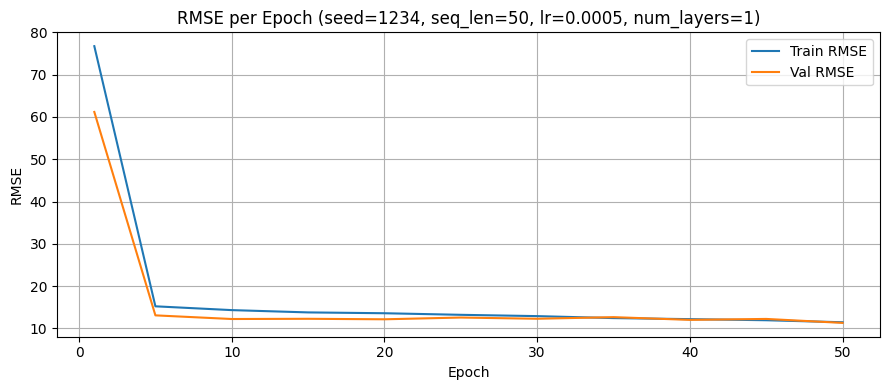

In [ ]:
# Extract and plot RMSE curve from best model found in hyperparameter optimisation block
import json, re, sys, pathlib
import pandas as pd
import matplotlib.pyplot as plt

NB_PATH = pathlib.Path("transformer-with-opt.ipynb")
if not NB_PATH.exists():
    print("Notebook not found:", NB_PATH); sys.exit(1)

with NB_PATH.open("r", encoding="utf-8") as f:
    nb = json.load(f)

# Patterns to capture: header, epoch lines, and the 'New best' summary line
header_pattern = re.compile(r'---\s*seed=(\d+),\s*seq_len=(\d+),\s*lr=([0-9.eE+-]+),\s*num_layers=(\d+)\s*---')
epoch_pattern = re.compile(r'Epoch\s+(\d+)[^\|]*\|\s*Train RMSE:\s*([0-9.]+)\s*\|\s*Val RMSE:\s*([0-9.]+)')
new_best_pattern = re.compile(r'✓\s*New best low variance model\s*\(Val RMSE:\s*([0-9.]+)\)\s*→\s*(\S+)')

# Aggregate parsed output by header (seed, seq_len, lr, num_layers)
parsed = {}
current = None

for cell in nb.get('cells', []):
    for out in cell.get('outputs', []):
        texts = []
        if out.get('output_type') == 'stream':
            texts.append(''.join(out.get('text', [])))
        elif 'data' in out and 'text/plain' in out['data']:
            texts.append(''.join(out['data']['text/plain']))
        elif 'text' in out:
            texts.append(''.join(out.get('text', [])))
        for t in texts:
            for line in t.splitlines():
                # Header start of a hyperparam run
                m = header_pattern.search(line)
                if m:
                    key = (int(m.group(1)), int(m.group(2)), float(m.group(3)), int(m.group(4)))
                    parsed.setdefault(key, {'epochs': [], 'best': None})
                    current = key
                    continue
                # Epoch metrics
                m2 = epoch_pattern.search(line)
                if m2:
                    ep = int(m2.group(1)); tr = float(m2.group(2)); va = float(m2.group(3))
                    if current is None:
                        current = ('_no_header_',)
                        parsed.setdefault(current, {'epochs': [], 'best': None})
                    parsed[current]['epochs'].append({'epoch': ep, 'train_rmse': tr, 'val_rmse': va, 'line': line})
                    continue
                # New-best summary line
                m3 = new_best_pattern.search(line)
                if m3:
                    val = float(m3.group(1)); path = m3.group(2)
                    if current is None:
                        current = ('_no_header_',)
                        parsed.setdefault(current, {'epochs': [], 'best': None})
                    parsed[current]['best'] = {'val_rmse': val, 'path': path, 'line': line}

# Target hyperparameters we want to display/plot
target = (1234, 50, 0.0005, 1)
# Find the exact or nearest matching key (tolerant on float equality for lr)
match_key = None
for key in parsed.keys():
    try:
        seed_k, seq_k, lr_k, nl_k = key
    except Exception:
        continue
    if seed_k == target[0] and seq_k == target[1] and nl_k == target[3] and abs(lr_k - target[2]) < 1e-12:
        match_key = key
        break
# Fallback: match seed/seq/num_layers ignoring tiny float mismatches
if match_key is None:
    for key in parsed.keys():
        try:
            seed_k, seq_k, lr_k, nl_k = key
        except Exception:
            continue
        if seed_k == target[0] and seq_k == target[1] and nl_k == target[3]:
            match_key = key
            break

if match_key is None:
    print('No matching hyperparam run found for', target)
else:
    entry = parsed[match_key]
    # Print header line
    print(f'--- seed={match_key[0]}, seq_len={match_key[1]}, lr={match_key[2]}, num_layers={match_key[3]} ---')
    # Print epoch lines sorted by epoch
    for r in sorted(entry['epochs'], key=lambda x: x['epoch']):
        print(r['line'])
    # Print new-best line if present
    if entry.get('best') is not None:
        print(entry['best']['line'])

    # Plot the curve if we have epochs
    if entry['epochs']:
        df = pd.DataFrame(sorted(entry['epochs'], key=lambda x: x['epoch']))
        plt.figure(figsize=(9,4))
        plt.plot(df['epoch'], df['train_rmse'], label='Train RMSE')
        plt.plot(df['epoch'], df['val_rmse'], label='Val RMSE')
        plt.xlabel('Epoch')
        plt.ylabel('RMSE')
        plt.title(f'RMSE per Epoch (seed={match_key[0]}, seq_len={match_key[1]}, lr={match_key[2]}, num_layers={match_key[3]})')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()